# ETL Lesson 3 – Practice 3: Data Exploration, Profiling, and Transformation

### Practice Objective:
The purpose of this practice is to guide you through the process of generating synthetic data, performing data profiling, and applying different cleaning and transformation techniques. This will allow you to handle null values, errors, duplicates, outliers, and anomalies in the data, ensuring that it’s ready for further analysis or machine learning models.

## 1) Generation of Synthetic Data with Errors
In this step, we will generate synthetic data, deliberately introduced with errors and missing values to simulate real-world situations.

In [13]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)

# Generate synthetic data
n_rows = 500

# Fields
product_ids = [f"P{str(i).zfill(4)}" for i in range(1, n_rows + 1)]
product_names = random.choices(["Laptop", "Shirt", "Book", "Phone", "Desk"], k=n_rows)
product_categories = ["electronics", "clothing", "office", "electronics", "office"]
cat_map = dict(zip(["Laptop", "Shirt", "Book", "Phone", "Desk"], product_categories))
categories = [cat_map[name] for name in product_names]

amounts_spent = np.random.normal(100, 30, n_rows) # Normal distribution with some negative outliers/extremes
customer_emails = [f"user{i}@example.com" for i in range(1, n_rows + 1)]
shipping_countries = random.choices(["USA", "Canada", "UK", "Germany", "France", "Spain"], k=n_rows)

# Product prices based on amount spent
product_prices = amounts_spent * 0.8
prices_str = [str(round(p, 2)) for p in product_prices]

# Dates
start_date = datetime(2023, 1, 1)
dates = [(start_date + timedelta(days=random.randint(0, 365))).strftime('%Y-%m-%d') for _ in range(n_rows)]

# Payment matches
payment_methods = random.choices(["credit card", "paypal", "debit card", "cash"], k=n_rows)

# Loyalty Scores
loyalty_scores = np.random.randint(1, 100, n_rows).astype(float)

# Introduce errors as requested:
# Erroneous Data: ProductPrice will have "NA" in some entries
for idx in random.sample(range(n_rows), 25):
    prices_str[idx] = "NA"
    
# Erroneous Emails: invalid-email
for idx in random.sample(range(n_rows), 20):
    customer_emails[idx] = "invalid-email"

# Null Values: PurchaseDate, AmountSpent, LoyaltyScore, ShippingCountry
dates_arr = np.array(dates, dtype=object)
dates_arr[random.sample(range(n_rows), 30)] = np.nan

loyalty_arr = np.array(loyalty_scores)
loyalty_arr[random.sample(range(n_rows), 40)] = np.nan

countries_arr = np.array(shipping_countries, dtype=object)
countries_arr[random.sample(range(n_rows), 25)] = np.nan

amounts_arr = np.array(amounts_spent)
amounts_arr[random.sample(range(n_rows), 35)] = np.nan

# Construct DataFrame
data = {
    "ProductID": product_ids,
    "ProductName": product_names,
    "ProductCategory": categories,
    "ProductPrice": prices_str,
    "CustomerEmail": customer_emails,
    "AmountSpent": amounts_arr,
    "LoyaltyScore": loyalty_arr,
    "PurchaseDate": dates_arr,
    "PaymentMethod": payment_methods,
    "ShippingCountry": countries_arr
}

df = pd.DataFrame(data)

# Introduce Outliers for Z-score testing later
outlier_indices = random.sample(range(n_rows), 10)
df.loc[outlier_indices, 'AmountSpent'] = np.random.uniform(1000, 5000, 10)
df.loc[outlier_indices, 'ProductPrice'] = [str(round(p, 2)) for p in np.random.uniform(800, 4000, 10)]

# Introduce Duplicates
duplicates = df.sample(20, random_state=42)
df = pd.concat([df, duplicates], ignore_index=True)

print("Generated DataFrame shape:", df.shape)
df.head(10)

Generated DataFrame shape: (520, 10)


,ProductID,ProductName,ProductCategory,ProductPrice,CustomerEmail,AmountSpent,LoyaltyScore,PurchaseDate,PaymentMethod,ShippingCountry
0,P0001,Phone,electronics,91.92,user1@example.com,114.901425,26.0,2023-02-20,cash,Germany
1,P0002,Laptop,electronics,2714.52,user2@example.com,4366.118641,64.0,2023-12-18,cash,USA
2,P0003,Shirt,clothing,95.54,user3@example.com,119.430656,98.0,2023-07-08,credit card,UK
3,P0004,Shirt,clothing,116.55,user4@example.com,145.690896,59.0,NaN,credit card,Germany
4,P0005,Phone,electronics,74.38,user5@example.com,92.975399,56.0,2023-11-27,cash,USA
5,P0006,Phone,electronics,74.38,user6@example.com,92.975891,59.0,NaN,cash,Germany
6,P0007,Desk,office,117.9,user7@example.com,147.376384,70.0,2023-02-01,cash,USA
7,P0008,Laptop,electronics,98.42,invalid-email,123.023042,33.0,2023-07-23,credit card,UK
8,P0009,Book,office,68.73,user9@example.com,85.915768,53.0,2023-05-22,debit card,USA
9,P0010,Laptop,electronics,93.02,user10@example.com,116.276801,22.0,2023-04-08,debit card,UK


## 2) Data Profiling Before Cleaning
Data profiling helps us identify issues before we begin to resolve them.

In [14]:
# 1. General Information
print("--- DataFrame Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
display(df.describe())


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ProductID        520 non-null    object 
 1   ProductName      520 non-null    object 
 2   ProductCategory  520 non-null    object 
 3   ProductPrice     520 non-null    object 
 4   CustomerEmail    520 non-null    object 
 5   AmountSpent      484 non-null    float64
 6   LoyaltyScore     478 non-null    float64
 7   PurchaseDate     490 non-null    object 
 8   PaymentMethod    520 non-null    object 
 9   ShippingCountry  495 non-null    object 
dtypes: float64(2), object(8)
memory usage: 40.8+ KB

--- Descriptive Statistics ---


,AmountSpent,LoyaltyScore
count,484.000000,478.000000
mean,163.354955,48.297071
std,457.776060,28.521933
min,21.407647,1.000000
25%,80.336694,25.000000
50%,102.297593,47.000000
75%,120.458589,72.000000
max,4820.945251,99.000000


--- Missing Values Count ---
ProductID           0
ProductName         0
ProductCategory     0
ProductPrice        0
CustomerEmail       0
AmountSpent        36
LoyaltyScore       42
PurchaseDate       30
PaymentMethod       0
ShippingCountry    25
dtype: int64


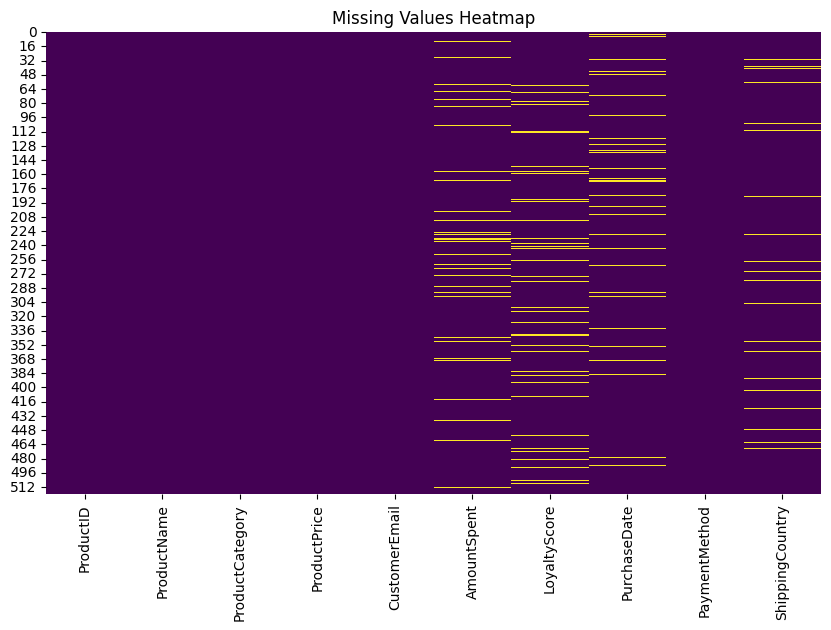

In [15]:
# 2. Missing Values
print("--- Missing Values Count ---")
print(df.isnull().sum())

# Heatmap for visualizing missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

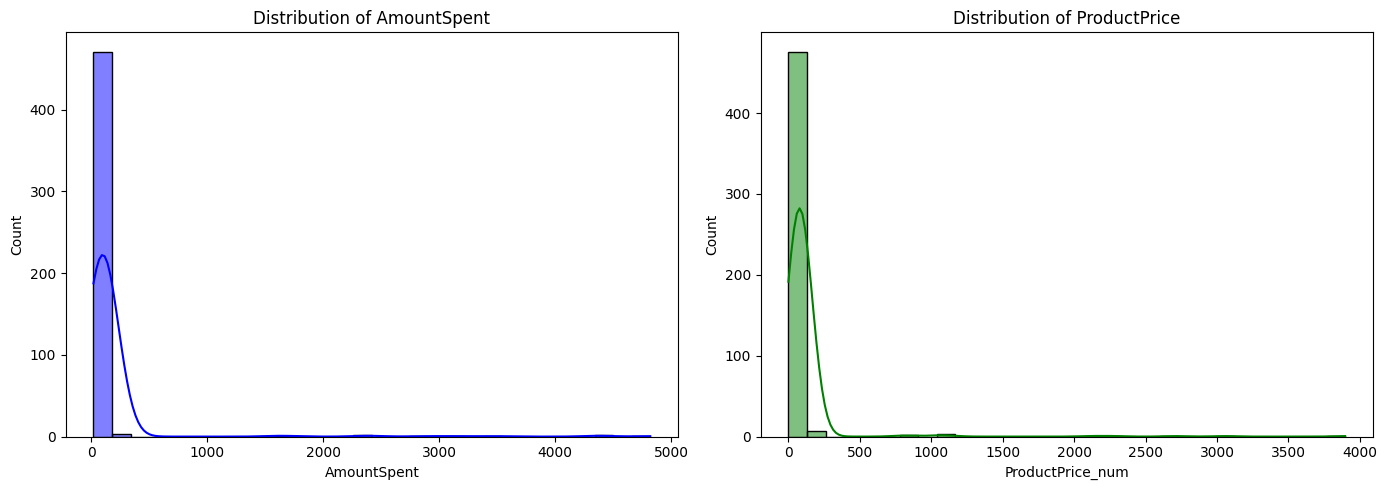

In [16]:
# 3. Distribution of Data

# Create a temporary numeric column for ProductPrice to plot properly
temp_df = df.copy()
temp_df['ProductPrice_num'] = pd.to_numeric(temp_df['ProductPrice'], errors='coerce')

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(temp_df['AmountSpent'].dropna(), kde=True, bins=30, color='blue')
plt.title('Distribution of AmountSpent')

plt.subplot(1, 2, 2)
sns.histplot(temp_df['ProductPrice_num'].dropna(), kde=True, bins=30, color='green')
plt.title('Distribution of ProductPrice')

plt.tight_layout()
plt.show()

Number of outliers in AmountSpent based on Z-score > 3: 10


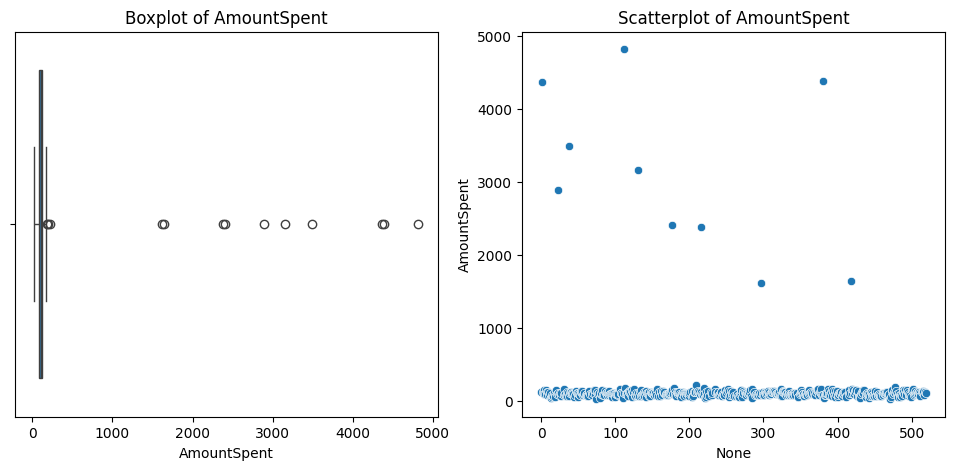

Number of duplicate rows: 20
Number of 'NA' string values in ProductPrice: 27
Number of 'invalid-email' values in CustomerEmail: 21


In [17]:
from scipy import stats

# 4. Anomaly Detection (Outliers)
plt.figure(figsize=(12, 5))

# Calculating Z-scores for AmountSpent
z_scores_amount = np.abs(stats.zscore(temp_df['AmountSpent'].dropna()))
outliers_amount = temp_df['AmountSpent'].dropna()[z_scores_amount > 3]
print(f"Number of outliers in AmountSpent based on Z-score > 3: {len(outliers_amount)}")

plt.subplot(1, 2, 1)
sns.boxplot(x=temp_df['AmountSpent'])
plt.title('Boxplot of AmountSpent')

plt.subplot(1, 2, 2)
sns.scatterplot(x=temp_df.index, y=temp_df['AmountSpent'])
plt.title('Scatterplot of AmountSpent')
plt.show()

# 5. Duplicate Detection
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# 6. Erroneous Values
num_na = (df['ProductPrice'] == "NA").sum()
print(f"Number of 'NA' string values in ProductPrice: {num_na}")

invalid_emails = (df['CustomerEmail'] == "invalid-email").sum()
print(f"Number of 'invalid-email' values in CustomerEmail: {invalid_emails}")

## 3) Data Cleaning and Transformation
We will now apply data cleaning and transformation techniques to ensure that the data is accurate, consistent, and ready for analysis.

In [18]:
# Step 1: Remove Duplicates
print(f"Original dataset shape: {df.shape}")
df_cleaned = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df_cleaned.shape}")

Original dataset shape: (520, 10)
Dataset shape after removing duplicates: (500, 10)


In [19]:
# Step 2: Imputation of Missing Values

# Impute AmountSpent with mean
mean_amount = df_cleaned['AmountSpent'].mean()
df_cleaned.loc[:, 'AmountSpent'] = df_cleaned['AmountSpent'].fillna(mean_amount)

# Impute LoyaltyScore with median
median_loyalty = df_cleaned['LoyaltyScore'].median()
df_cleaned.loc[:, 'LoyaltyScore'] = df_cleaned['LoyaltyScore'].fillna(median_loyalty)

# Impute PurchaseDate
df_cleaned.loc[:, 'PurchaseDate'] = df_cleaned['PurchaseDate'].fillna("2025-01-01")

# Impute ShippingCountry
df_cleaned.loc[:, 'ShippingCountry'] = df_cleaned['ShippingCountry'].fillna("Unknown")

# Impute ProductPrice
df_cleaned.loc[:, 'ProductPrice'] = pd.to_numeric(df_cleaned['ProductPrice'], errors='coerce')
mean_price = df_cleaned['ProductPrice'].mean()
df_cleaned.loc[:, 'ProductPrice'] = df_cleaned['ProductPrice'].fillna(mean_price)

print("Remaining Null values after imputation:")
print(df_cleaned.isnull().sum())

Remaining Null values after imputation:
ProductID          0
ProductName        0
ProductCategory    0
ProductPrice       0
CustomerEmail      0
AmountSpent        0
LoyaltyScore       0
PurchaseDate       0
PaymentMethod      0
ShippingCountry    0
dtype: int64


In [20]:
# Step 3: Handle Outliers
# Filter out records with Z-score > 3 for AmountSpent and ProductPrice
df_cleaned['AmountSpent'] = df_cleaned['AmountSpent'].astype(float)
df_cleaned['ProductPrice'] = df_cleaned['ProductPrice'].astype(float)

z_amount = np.abs(stats.zscore(df_cleaned['AmountSpent']))
z_price = np.abs(stats.zscore(df_cleaned['ProductPrice']))

df_cleaned = df_cleaned[(z_amount <= 3) & (z_price <= 3)]

print(f"Dataset shape after removing outliers: {df_cleaned.shape}")

Dataset shape after removing outliers: (490, 10)


In [21]:
# Step 4: Standardize Data
import datetime

# Standardize ProductCategory capitalization
df_cleaned.loc[:, 'ProductCategory'] = df_cleaned['ProductCategory'].str.title()

# Convert PurchaseDate to a consistent YYYY-MM-DD format
df_cleaned.loc[:, 'PurchaseDate'] = pd.to_datetime(df_cleaned['PurchaseDate']).dt.strftime('%Y-%m-%d')

# Normalize PaymentMethod by capitalizing the first letter of each word
df_cleaned.loc[:, 'PaymentMethod'] = df_cleaned['PaymentMethod'].str.title()

# Step 5: Generate New Business Metrics

# Sales by Product Category
sales_by_category = df_cleaned.groupby('ProductCategory')['AmountSpent'].sum().reset_index()
print("Sales by Product Category:")
print(sales_by_category)
print("\n")

# Top 5 Customers by total spending
top_customers = df_cleaned.groupby('CustomerEmail')['AmountSpent'].sum().reset_index().sort_values(by='AmountSpent', ascending=False).head(5)
print("Top 5 Customers:")
display(top_customers)

Sales by Product Category:
  ProductCategory   AmountSpent
0        Clothing  11503.145415
1     Electronics  18961.852847
2          Office  21061.154810


Top 5 Customers:


,CustomerEmail,AmountSpent
0,invalid-email,2110.679795
116,user210@example.com,215.581945
394,user479@example.com,192.366424
83,user180@example.com,181.605075
15,user114@example.com,173.897263


## 4) Profiling Post-Cleaning
After applying the necessary cleaning and transformations, perform a final round of profiling to ensure the data is ready for analysis.

In [22]:
# Final profiling statistics
print("--- Cleaned DataFrame Info ---")
df_cleaned.info()

print("\n--- Cleaned Descriptive Statistics ---")
display(df_cleaned.describe())

print("\n--- Null Values Count After Cleaning ---")
print(df_cleaned.isnull().sum())

--- Cleaned DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 490 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ProductID        490 non-null    object 
 1   ProductName      490 non-null    object 
 2   ProductCategory  490 non-null    object 
 3   ProductPrice     490 non-null    float64
 4   CustomerEmail    490 non-null    object 
 5   AmountSpent      490 non-null    float64
 6   LoyaltyScore     490 non-null    float64
 7   PurchaseDate     490 non-null    object 
 8   PaymentMethod    490 non-null    object 
 9   ShippingCountry  490 non-null    object 
dtypes: float64(3), object(7)
memory usage: 42.1+ KB

--- Cleaned Descriptive Statistics ---


,ProductPrice,AmountSpent,LoyaltyScore
count,490.000000,490.000000,490.000000
mean,82.065723,105.155414,48.634694
std,24.431930,32.695620,27.310590
min,2.210000,21.407647,1.000000
25%,64.330000,81.476461,27.000000
50%,82.025000,103.366599,49.000000
75%,98.370000,124.219301,70.000000
max,172.470000,215.581945,99.000000



--- Null Values Count After Cleaning ---
ProductID          0
ProductName        0
ProductCategory    0
ProductPrice       0
CustomerEmail      0
AmountSpent        0
LoyaltyScore       0
PurchaseDate       0
PaymentMethod      0
ShippingCountry    0
dtype: int64


## 5) Final Visualizations
To conclude the practice, create the following visualizations to compare the data before and after cleaning:
- Z-plots to visualize how outliers have been reduced
- Boxplots to visualize the distribution of AmountSpent and ProductPrice before and after cleaning
- Histograms to show the frequency distribution of key numeric columns

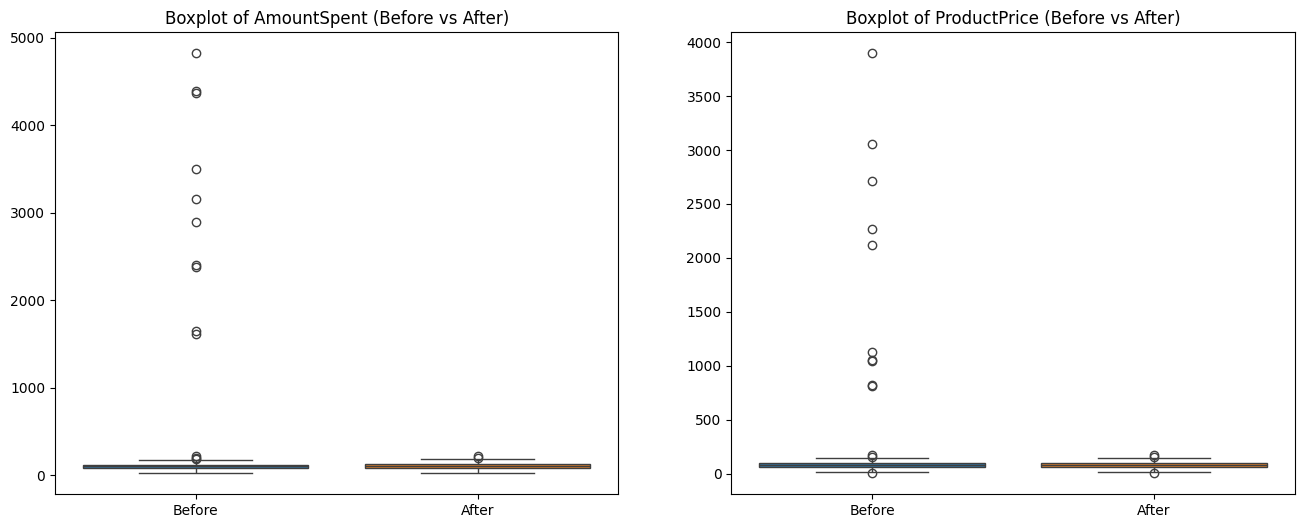

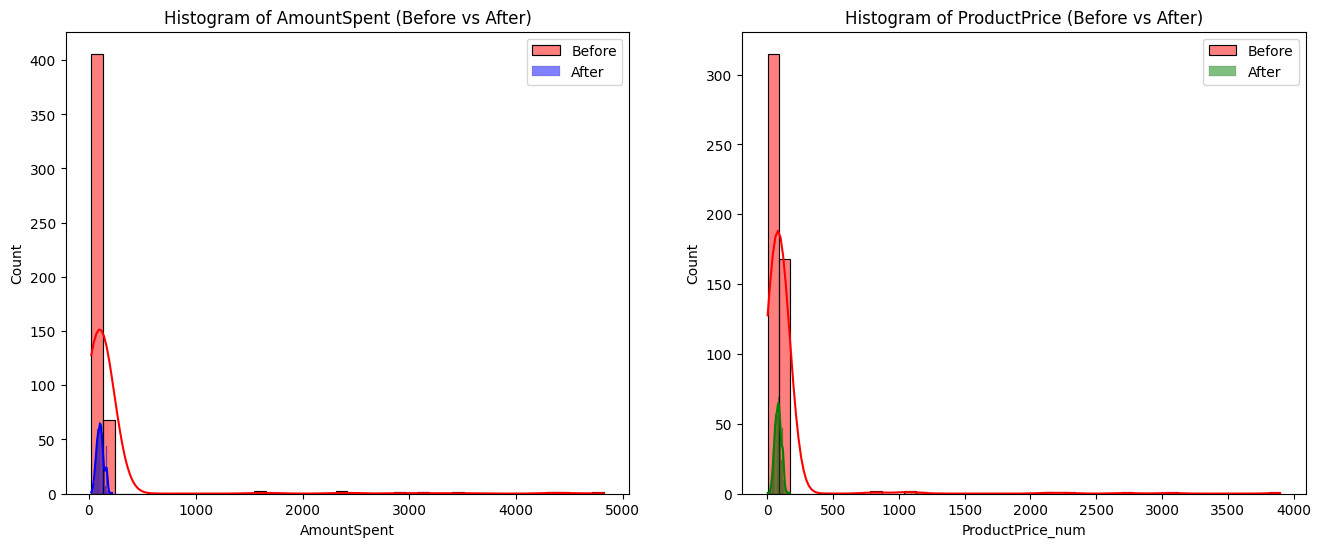

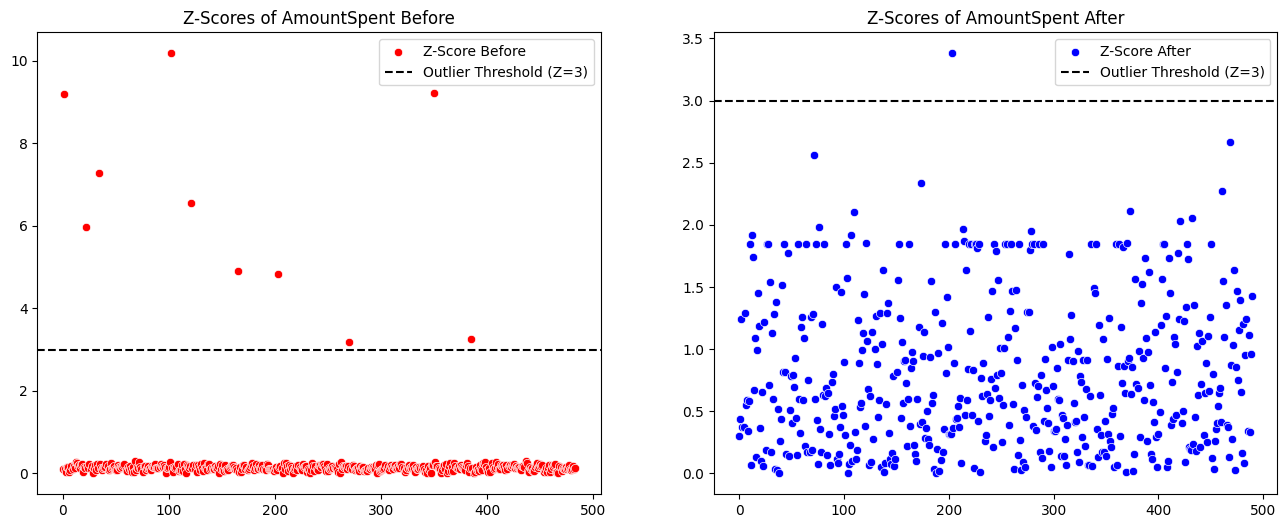

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Calculate Z-scores for visualization
z_amount_before = np.abs(stats.zscore(temp_df['AmountSpent'].dropna()))
z_amount_after = np.abs(stats.zscore(df_cleaned['AmountSpent']))

plt.figure(figsize=(16, 6))

# Boxplots Before and After
plt.subplot(1, 2, 1)
sns.boxplot(data=pd.DataFrame({'Before': temp_df['AmountSpent'], 'After': df_cleaned['AmountSpent']}))
plt.title('Boxplot of AmountSpent (Before vs After)')

plt.subplot(1, 2, 2)
sns.boxplot(data=pd.DataFrame({'Before': temp_df['ProductPrice_num'], 'After': df_cleaned['ProductPrice']}))
plt.title('Boxplot of ProductPrice (Before vs After)')
plt.show()

# Histograms Before and After
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.histplot(temp_df['AmountSpent'].dropna(), kde=True, color='red', alpha=0.5, label='Before')
sns.histplot(df_cleaned['AmountSpent'], kde=True, color='blue', alpha=0.5, label='After')
plt.title('Histogram of AmountSpent (Before vs After)')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(temp_df['ProductPrice_num'].dropna(), kde=True, color='red', alpha=0.5, label='Before')
sns.histplot(df_cleaned['ProductPrice'], kde=True, color='green', alpha=0.5, label='After')
plt.title('Histogram of ProductPrice (Before vs After)')
plt.legend()
plt.show()

# Z-scores Scatter Plots Before and After
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=range(len(z_amount_before)), y=z_amount_before, color='red', label='Z-Score Before')
plt.axhline(y=3, color='black', linestyle='--', label='Outlier Threshold (Z=3)')
plt.title('Z-Scores of AmountSpent Before')
plt.legend()

plt.subplot(1, 2, 2)
sns.scatterplot(x=range(len(z_amount_after)), y=z_amount_after, color='blue', label='Z-Score After')
plt.axhline(y=3, color='black', linestyle='--', label='Outlier Threshold (Z=3)')
plt.title('Z-Scores of AmountSpent After')
plt.legend()
plt.show()

In [24]:
# Save final datasets
temp_df.to_csv('practice3_raw_data.csv', index=False)
df_cleaned.to_csv('practice3_clean_data.csv', index=False)
print("Saved practice3_raw_data.csv and practice3_clean_data.csv")

Saved practice3_raw_data.csv and practice3_clean_data.csv
